In [1]:
# You may add additional imports here
import random
import matplotlib.pyplot as plt
import csv

from IPython.display import clear_output

Question 1
==========

All parts of Question 1 use the _point-a-rally (PARS) scoring_ system.

**Question 1a:** Complete the following function so that it implements the PARS algorithm from the coursework specification.

**[Functionality: 7 marks]**

In [2]:
def game(ra, rb):
    probability_a_wins = ra / (ra + rb)

    score_a = 0
    score_b = 0
    should_game_continue = True

    while should_game_continue:
        if random.random() < probability_a_wins:
            score_a += 1
        else:
            score_b += 1
        
        if score_a >= 11 or score_b >= 11:
            if abs(score_a - score_b) >= 2:
                should_game_continue = False

    return (score_a, score_b)

**Testing:** If the random seed is set to 57, then calling the function with arguments `70` and `30` should return `(11,5)`.

In [3]:
random.seed(57)
print(game(70, 30))

(11, 5)


**Question 1b:** Complete the following function `win_probability_game(ra, rb, simulations)` to simulate `simulations` games in order to estimate the probability that a player with ability `ra` will win a game against a player of ability `rb`.

**[Functionality: 4 marks]**

In [4]:
def win_probability_game(ra, rb, simulations):
    games_won_a = 0

    for _ in range(0, simulations):
        score_a, score_b = game(ra, rb)

        if score_a > score_b:
            games_won_a += 1

    return games_won_a / simulations


**Testing:** Given sufficient simulations, calling the function with abilities `70` and `30` should give the answer `0.98` when printed to 2 decimal places.

In [5]:
# Print win_probability_game(70, 30) to 2 decimal places for a suitable value of n:
print(round(win_probability_game(70, 30, 10000), 2))

0.98


**Question 1c:** Assume players abilities are given in a csv file with the format:
```
player a ability, player b ability,
60, 20,
100, 55,
50, 40,
20, 70,
95, 85,
```
Complete the following function to read in a specified csv file of this format and return a `list` of `tuple`s containing each pair of abilities.

**[Functionality: 4 marks]**

In [6]:
def read_abilities(file_path):
    abilities = []

    with open(file_path) as csv_file:
        csv_contents = csv.reader(csv_file)

        for row in csv_contents:
            if row[0].isdigit():
                ra = int(row[0])
                rb = int(row[1])

                abilities.append((ra, rb))

    return abilities


**Testing:** Calling the function to read the file `test.csv` from Learning Central should return `[(60, 20), (100, 55), (50, 40), (20, 70), (95, 85)]`

In [7]:
# Print the result of calling the function for the file `test.csv`
abilities = read_abilities("test.csv")
print(abilities)

[(60, 20), (100, 55), (50, 40), (20, 70), (95, 85)]


**Question 1d:** Write a function that takes a `list` of the format returned by your answer to 1c as an argument, and uses `matplotlib` to produce a plot (with labelled axes) showing the probability that player a beats player b (in a game) against `ra / r_b` for each pair.

**[Functionality: 5 marks]**

In [8]:
def plot_win_probabilities(abilities):
    x = []
    y = []

    for ra, rb in abilities:
        x.append(ra / rb)
        y.append(win_probability_game(ra, rb, 10000))
    
    plt.plot(x, y, "bo")
    plt.show()

**Testing:** The following figure (or similar) should result from the data `[(60, 20), (100, 55), (50, 40), (20, 70), (95, 85)]'

<img src="./win_probabilities.png" alt="Win probabilities" width="500">


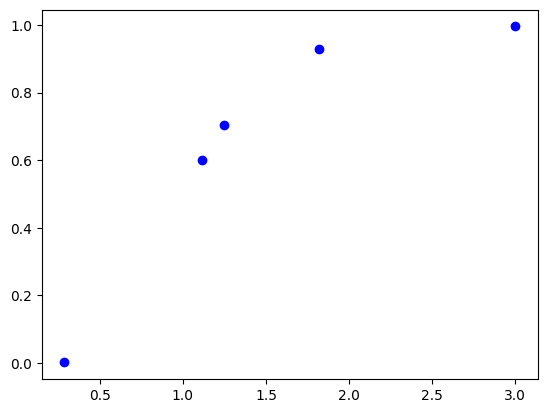

In [9]:
# Call the function to plot the figure here
plot_win_probabilities(abilities)

**Question 1e:** Complete the following function `win_probability_match(ra, rb, simulations, m)` to simulate `simulations` matches which are won by the first player to win `m` games, and returns an estimate of the probability that a player with ability `ra` will win such a match against a player of ability `rb`.

Provide code that works out the smallest value of `m` such that `win_probability_match(60, 40, simulations, m)` is at least `0.9`. 

_HINT: make sure you use an appropriate value for `simulations`._

**[Functionality: 5 marks]**

In [10]:
def match(ra, rb, m):
    games_won_a = 0
    games_won_b = 0

    match_should_continue = True

    while match_should_continue:
        score_a, score_b = game(ra, rb)

        if score_a > score_b:
            games_won_a += 1
        else:
            games_won_b += 1

        if games_won_a >= m or games_won_b >= m:
            match_should_continue = False

    return (games_won_a, games_won_b)

In [11]:
def win_probability_match(ra, rb, simulations, m):
    matches_won_a = 0

    for _ in range(0, simulations):
        games_won_a, games_won_b = match(ra, rb, m)

        if games_won_a > games_won_b:
            matches_won_a += 1

    return matches_won_a / simulations


# Calculate lowest value of m here
probability_a_wins = 0
m = 0

while probability_a_wins < 0.9:
    m += 1
    probability_a_wins = win_probability_match(60, 40, 10000, m)

print(m)


2


Question 2
==========

Complete the remaining template of a scientific report that uses the results of simulation (with suitable input data) to investigate whether English or PARS is the ``better'' scoring method for squash matches. 

You should clearly state any assumptions you make, and may add any number of code cells. Guidance for completing the markdown/text cells is given in the coursework specification. The word count of the remaining markdown/text cells must be at most 750.

Your investigation should consider the relative ability of the two players (i.e. `ra/rb`) as the _independent variable_ and include appropriate figures that show how your choice of relevant _dependent variable_ varies. Your results **must** cover at least 50 different values of `ra/rb`.

Some starting points you may consider:
- How _fair_ is the scoring method - does the better player usually win?
- Shorter matches are usually preferable (e.g. for television) - if you assume each rally in a match takes equal time, how long do matches typically last?
- What effect does the relative ability of the two players have?

**[Report: 7 marks; Achievement: 8 marks]**

## Problem

The problem is which is better, the PARS system or the English system for squash matches. First, we must define what better means. In this case we define better as if a player A is better than another player B then player A should have a higher chance to win a match against player B. We should also consider the spectator's perspective when watching the game. This includes whether the game between the 2 players are close and the length of the game to keep the spectators interested.

## Method

We will give the 2 players a value representing their ability and calculate a probability for the player A to win from these ability values against player B. In order to display results of varying abilities, I will plot the relative ability between the 2 players, `player_a_ability / player_b_ability` on the x-axis. I will be measuring the probability of player A winning, the number of rounds played to estimate the length of the game and the difference between the scores of the games. Using python, we can simulate the 2 scoring systems by calculating the probabilty that player A wins a point using `player_a_ability / (player_a_ability + player_b_ability)` with the help of the `random` function from the `random` module. From this we can implement the scoring systems in python and repeat these multiple times to get the required data. In order to get the most accurate results, we must run the at least 1000 simulations per pair of player abilities, repeating these for a few hundred different pairs of player abilities.

## Assumptions

- The players ability is constant throughout the match, i.e. they don't get tired or adapt to the other player etc.
    - This is unrealistic for a game between 2 players and for this simulation, we will assume all aspects of the player can be summarised into 1 number which is their ability.
- When starting a game using the English system, there is a 50% chance that each player will start out as the server.
    - This could alter depending on the rules of the tournament or match they are playing in.
- When an English game has reached 8-8, there is a 50% chance that the game will last to either 9 or 10 points.
    - There may be a strategy in which a player should choose one or the other, in this case we will not look into it.
- The `random` function from the `random` module is truly random
    - Random numbers generated from a computer are pseudo-random and may favour in 1 direction depending on how the algorithm is seeded.

## Results

In [12]:
def pars_game(probability_a_wins_point):
    score_a = 0
    score_b = 0
    rounds = 0

    should_game_continue = True

    while should_game_continue:
        if random.random() < probability_a_wins_point:
            score_a += 1
        else:
            score_b += 1

        rounds += 1

        if score_a >= 11 or score_b >= 11:
            if abs(score_a - score_b) >= 2:
                should_game_continue = False

    return (score_a, score_b, rounds)


def english_game(probability_a_wins_point):
    if random.random() < 0.5:
        server = "player_a"
    else:
        server = "player_b"

    score_a = 0
    score_b = 0
    rounds = 0

    should_game_continue = True
    reached_draw = False
    play_to_score = 9

    while should_game_continue:
        if random.random() < probability_a_wins_point:
            if server == "player_a":
                score_a += 1
            else:
                server = "player_a"
        else:
            if server == "player_a":
                server = "player_b"
            else:
                score_b += 1

        rounds += 1

        if reached_draw is False:
            if score_a >= 9 or score_b >= 9:
                should_game_continue = False
            elif score_a == 8 and score_b == 8:
                if random.random() < 0.5:
                    play_to_score = 10
                reached_draw = True
        else:
            if score_a >= play_to_score or score_b >= play_to_score:
                should_game_continue = False

    return (score_a, score_b, rounds)

In [13]:
def simulate_match(game_type, probability_a_wins_point, games_to_win):
    games_won_a = 0
    games_won_b = 0
    rounds_played = 0
    score_difference = 0

    match_should_continue = True

    while match_should_continue:
        score_a, score_b, rounds = game_type(probability_a_wins_point)

        rounds_played += rounds
        score_difference += abs(score_a - score_b)

        if score_a > score_b:
            games_won_a += 1
        else:
            games_won_b += 1

        if games_won_a >= games_to_win or games_won_b >= games_to_win:
            match_should_continue = False

    return (games_won_a, games_won_b, rounds_played, score_difference)


def probability_a_wins_match(game_type, probability_a_wins_point, games_to_win, simulations):
    matches_won_a = 0
    total_rounds_played = 0
    total_score_difference = 0

    for _ in range(0, simulations):
        games_won_a, games_won_b, rounds_played, score_difference = simulate_match(game_type, probability_a_wins_point, games_to_win)

        total_rounds_played += rounds_played
        total_score_difference += score_difference

        if games_won_a > games_won_b:
            matches_won_a += 1

    return (matches_won_a / simulations, total_rounds_played / simulations, total_score_difference / simulations)

In [14]:
def run_simulations(calculations, games_to_win, simulations):
    relative_abilities = []

    pars_winrate = []
    pars_rounds_played = []
    pars_score_difference = []
    english_winrate = []
    english_rounds_played = []
    english_score_difference = []

    ability_range_start = calculations // 2
    ability_range_end = calculations + ability_range_start

    player_b_ability = calculations

    for player_a_ability in range(ability_range_start, ability_range_end):
        print(f'{round((player_a_ability - ability_range_start) / calculations * 100, 2)}% Completed')

        probability_a_wins_point = player_a_ability / (player_a_ability + player_b_ability)

        pars_simulation = probability_a_wins_match(pars_game, probability_a_wins_point, games_to_win, simulations)
        english_simulation = probability_a_wins_match(english_game, probability_a_wins_point, games_to_win, simulations)

        relative_abilities.append(player_a_ability / player_b_ability)
        pars_winrate.append(pars_simulation[0])
        pars_rounds_played.append(pars_simulation[1])
        pars_score_difference.append(pars_simulation[2])
        english_winrate.append(english_simulation[0])
        english_rounds_played.append(english_simulation[1])
        english_score_difference.append(english_simulation[2])

    clear_output()

    plt.xlabel("Relative Win Probability (player_a_ability / player_b_ability)")
    plt.ylabel("Probability A Wins a Match")
    plt.plot(relative_abilities, pars_winrate, label="pars")
    plt.plot(relative_abilities, english_winrate, label="english")
    plt.legend()
    plt.show()

    plt.xlabel("Relative Win Probability (player_a_ability / player_b_ability)")
    plt.ylabel("Average Number of Rounds Played")
    plt.plot(relative_abilities, pars_rounds_played, label="pars")
    plt.plot(relative_abilities, english_rounds_played, label="english")
    plt.legend()
    plt.show()

    plt.xlabel("Relative Win Probability (player_a_ability / player_b_ability)")
    plt.ylabel("Score Difference Between Players")
    plt.plot(relative_abilities, pars_score_difference, label="pars")
    plt.plot(relative_abilities, english_score_difference, label="english")
    plt.legend()
    plt.show()

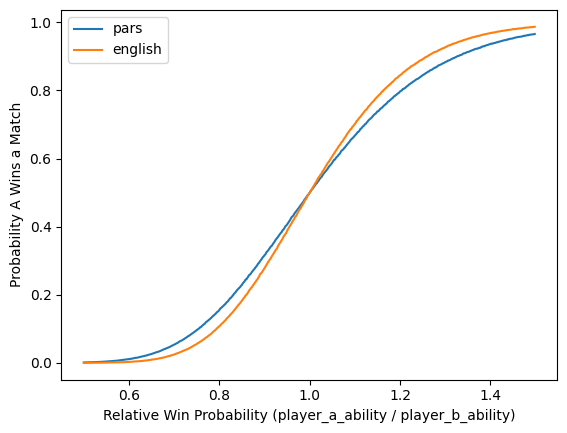

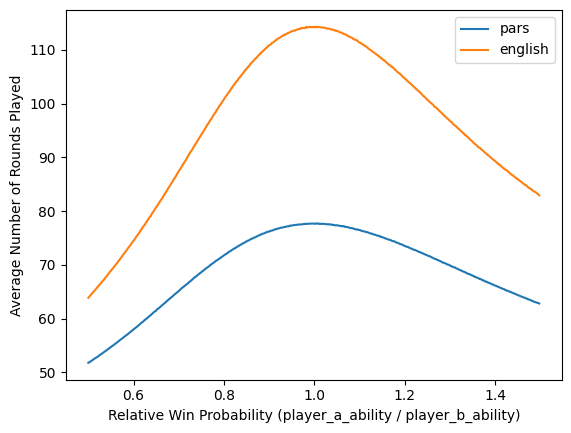

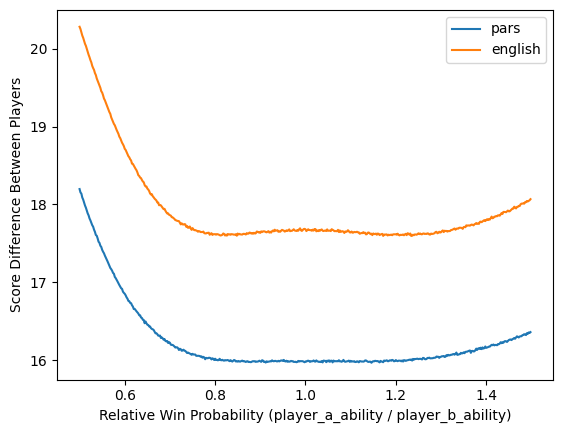

In [15]:
run_simulations(500, 3, 500000)

The English system favours the player with the higher ability more than the PARS system. This means if a player A has a higher ability than player B then player A is more likely to win than player B with the English system compared to the PARS system. However, the English system has longer matches, plus the fact that the PARS system has closer games which makes the PARS game more interesting to watch for spectators.

## Conclusions

The 2 different scoring systems has its own advantages depending on what your looking for. The English system is better for competitive matches since it is fairer. However, for watching the match from a spectator's perspective, the PARS system is more entertaining due to its shorter matches and closer games.